<a href="https://colab.research.google.com/github/STARG-LEE/colab/blob/main/notebooks/ESG_02_Financial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [개별기업] 재무 데이터 수집 & 분석

| 항목 | 내용 |
|---|---|
| **수집 방법** | WiseReport (Selenium + requests) |
| **수집 항목** | 매출액·당기순이익·총자산·유동자산·유동부채·자기자본·수정주가·수정주식수 |
| **분석** | 수익성·성장성·안정성·유동성·레이더차트·업종비교 |
| **DB** | `○○○.○○○.○○○.○○ (비밀) / cha_stock / tbl_financial` |


---
# ⚙️ 섹션 0 : 분석가 설정 (이 셀 하나만 수정하면 됩니다)

> **세 노트북(ESG_01 · ESG_02 · ESG_03)에서 아래 설정 셀은 글자 하나까지 똑같습니다.**
> 한 번만 값을 채운 뒤, 같은 내용을 세 노트북에 그대로 붙여넣으세요.
> 다른 셀은 건드릴 필요가 없습니다. 위에서 아래로 실행만 하면 됩니다.

| 무엇을 정해야 하나 | 변수 | 쓰는 곳 |
|---|---|---|
| 분석할 기업 | `STOCK_CODE` · `COMPANY_NAME` · `SEARCH_KEYWORD` · `TOPIC_CODE` | 01·02·03 공통 |
| DB 접속 | `DB_*` | 01·02·03 공통 |
| 주가 차트/시뮬레이션 | `STOCK_START_DATE` · `CHART_YEARS` · `BUY_DATE` · `INVEST_AMT` | 01 |
| 뉴스 기간·옵션 | `START_DATE` · `END_DATE` · `PHOTO_TYPE` · `REG_START_OFFSET` | 03 |
| 외부 키 | `OPENAI_API_KEY` · `GITHUB_TOKEN` (Colab 🔑 비밀) | 03 |


In [1]:
# ╔════════════════════════════════════════════════════════════════════╗
# ║                 ⚙️  분 석 가  설 정   (ANALYST CONFIG)              ║
# ║   이 셀은 ESG_01 · ESG_02 · ESG_03 에서 100% 동일합니다.            ║
# ║   여기 적힌 값만 바꾸면 됩니다. 아래 다른 셀은 수정하지 마세요.     ║
# ║   ⚠️ 비밀번호·API키는 코드에 적지 않습니다 → 아래 (5) 비밀 참고     ║
# ╚════════════════════════════════════════════════════════════════════╝
import os as _os

def _secret(name, default=''):
    """비밀값을 Colab 🔑(비밀) → 환경변수 순서로 읽음. 코드에 평문 저장 안 함."""
    try:
        from google.colab import userdata as _ud
        v = _ud.get(name)
        if v:
            return v
    except Exception:
        pass
    return _os.environ.get(name, default)

# ┌─ 1) 분석 대상 기업  (01·02·03 공통) ───────────────────────────────┐
STOCK_CODE     = '036930'         # 종목코드 6자리
COMPANY_NAME   = '주성엔지니어링'     # 회사명 (그래프 제목 등에 표시)
SEARCH_KEYWORD = '주성엔지니어링'     # 뉴스 검색어            (03 사용)
TOPIC_CODE     = 'JSEN'          # 뉴스 테이블 접미사(영문) (03 사용)

# ┌─ 2) DB 접속  (01·02·03 공통) ──────────────────────────────────────┐
#    호스트/아이디/비밀번호는 코드에 적지 않습니다.
#    Colab 🔑(비밀)에 DB_HOST · DB_USER · DB_PASSWORD 를 등록하세요.
DB_HOST     = _secret('DB_HOST')
DB_USER     = _secret('DB_USER')
DB_PASSWORD = _secret('DB_PASSWORD')
DB_NAME     = 'cha_stock'         # DB 이름(비밀 아님)
TABLE_NAME  = 'tbl_stock_price'   # 01 주가 테이블
FIN_TABLE   = 'tbl_financial'     # 02 재무 테이블

# ┌─ 3) [ESG_01 주가] 전용 ────────────────────────────────────────────┐
STOCK_START_DATE = '19970101'     # 주가 수집 시작일(YYYYMMDD) · 이어받기 자동
CHART_YEARS = 3                   # 차트 기본 표시 기간(년)
MA_PERIODS  = [5, 20, 60, 120, 240]   # 이동평균선
BUY_DATE    = '2022-01-03'        # 투자 시뮬레이션 매수일
INVEST_AMT  = 10_000_000          # 투자 시뮬레이션 금액(원)

# ┌─ 4) [ESG_03 뉴스·ESG] 전용 ────────────────────────────────────────┐
START_DATE = '2026-04-01'         # 뉴스 수집 시작일(포함)
END_DATE   = '2026-04-08'         # 뉴스 수집 종료일(포함)
PHOTO_TYPE = 3                    # 0=전체 1=포토 2=동영상 3=지면 4=보도자료
REG_START_OFFSET = 0              # 회귀 시작연도: 0=전체 / +N=앞N년 제외 / -N=자동보정

MAX_WORKERS          = 5          # 동시 처리 스레드 수
SIMILARITY_THRESHOLD = 0.4        # ESG 이슈 매칭 코사인 임계값
ESG_TABLE            = 'ESG_ISSUES_EMBED'
TOP_N_ISSUES         = 5          # 상위 ESG 이슈 개수
MOVING_AVG_WINDOW    = 12         # 이동평균 개월
MAX_LAG_MONTHS       = 12         # 시차 회귀 최대 개월
N_CLUSTERS           = 4          # 주제 군집 수
MIN_ARTICLES         = 10
TARGET_ESG_ISSUES    = []

# ┌─ 5) 외부 API 키 / 비밀  (03에서만 필요 · 01/02는 무시) ────────────┐
#    Colab: 왼쪽 🔑(비밀) 메뉴에 아래 이름으로 등록하세요.
#      OPENAI_API_KEY · GITHUB_TOKEN · DB_HOST · DB_USER · DB_PASSWORD
OPENAI_KEY   = _secret('OPENAI_API_KEY')
GITHUB_TOKEN = _secret('GITHUB_TOKEN')

GITHUB_USERNAME = 'STARG-LEE'  # ← 본인 GitHub 계정으로 변경 (03 HTML 업로드용)
GITHUB_REPO     = 'STOCK_ANALYZE' # 바꾸지 말 것
GITHUB_BRANCH   = 'main'          # 바꾸지 말 것
GITHUB_FOLDER   = 'storybooks'    # 바꾸지 말 것

print('⚙️ 분석가 설정 로드 완료:', COMPANY_NAME, '('+STOCK_CODE+')')
if not (DB_HOST and DB_USER and DB_PASSWORD):
    print('   ⚠️ DB 비밀 미설정 — Colab 🔑 비밀에 DB_HOST/DB_USER/DB_PASSWORD 등록 필요')


⚙️ 분석가 설정 로드 완료: 주성엔지니어링 (036930)


---
# 섹션 2 : 설치 및 초기화

In [2]:
!pip install -q pymysql sqlalchemy koreanize-matplotlib selenium webdriver-manager beautifulsoup4
print('설치 완료!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 10.5 MB/s eta 0:00:00
설치 완료!


In [3]:
%matplotlib inline
print('차트 인라인 표시 설정 완료!')

차트 인라인 표시 설정 완료!


In [4]:
import re, json, time, warnings
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pymysql, requests
from bs4 import BeautifulSoup
from sqlalchemy import create_engine, text
import koreanize_matplotlib
warnings.filterwarnings('ignore')

# Colab 인라인 표시
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except: pass

# DB 자동 생성
_tmp = pymysql.connect(host=DB_HOST, user=DB_USER, password=DB_PASSWORD,
                        charset='utf8mb4', autocommit=True)
_tmp.cursor().execute(
    'CREATE DATABASE IF NOT EXISTS `'+DB_NAME+'`'
    ' DEFAULT CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci')
_tmp.close()

engine = create_engine(
    'mysql+pymysql://'+DB_USER+':'+DB_PASSWORD
    +'@'+DB_HOST+'/'+DB_NAME+'?charset=utf8mb4')

PALETTE = {
    'blue':'#3B82F6','green':'#10B981','red':'#EF4444',
    'amber':'#F59E0B','purple':'#8B5CF6','teal':'#14B8A6',
    'pink':'#EC4899','gray':'#6B7280',
}

print('초기화 완료!')
print('  분석 기업:', COMPANY_NAME, '('+STOCK_CODE+')')
print('  DB:', DB_HOST, '/', DB_NAME, '/', FIN_TABLE)


초기화 완료!
  분석 기업: 주성엔지니어링 (036930)
  DB: 106.247.236.2 / cha_stock / tbl_financial


---
# 섹션 3 : 재무 데이터 수집

WiseReport에서 최근 5개년 재무데이터를 수집합니다.

```
3-1  Chrome 설치
3-2  수집 함수 정의
3-3  DB 테이블 생성
3-4  수집 실행 + DB 저장
```

> 이미 수집되어 있으면 자동으로 건너뜁니다.


In [5]:
# Chrome 설치 (Colab 전용)
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb > /dev/null 2>&1
print('Chrome 설치 완료!')


Chrome 설치 완료!


In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import json as _json

def get_driver():
    opts = Options()
    opts.add_argument('--headless=new')
    opts.add_argument('--no-sandbox')
    opts.add_argument('--disable-dev-shm-usage')
    opts.add_argument('--disable-gpu')
    opts.add_argument('--remote-debugging-port=9222')
    opts.binary_location = '/usr/bin/google-chrome'
    return webdriver.Chrome(
        service=Service(ChromeDriverManager().install()), options=opts)

def fetch_financial_data(code, name):
    driver = get_driver()
    try:
        # 1. Selenium으로 페이지 열어 세션 설정
        url = f'https://navercomp.wisereport.co.kr/v2/company/c1030001.aspx?cmp_cd={code}'
        driver.get(url)
        time.sleep(1)

        # 2. requests로 encparam 추출
        resp = requests.get(url)
        soup_str = str(BeautifulSoup(resp.text, 'html.parser'))
        enc_m = re.search(r"encparam: '(.*?)'", soup_str)
        if not enc_m:
            print(f'  encparam 없음: {name} ({code})')
            return None
        enc = enc_m.group(1)

        fin = {}; years = None

        for rtype, rpt, api in [
            ('income',  0, 'cF3002'),
            ('balance', 1, 'cF3002'),
            ('market',  5, 'cF4002'),
        ]:
            url1 = (f'https://navercomp.wisereport.co.kr/v2/company/{api}.aspx'
                    f'?cmp_cd={code}&frq=0&rpt={rpt}&finGubun=MAIN&frqTyp=0&cn=&encparam={enc}')

            # Selenium으로 창 열어 세션 유지
            driver.execute_script(f"window.open('{url1}')")
            time.sleep(1)

            r2 = requests.get(url1)
            parsed = _json.loads(r2.text)

            if years is None:
                cleaned = [re.sub('<br />', '', i) for i in parsed['YYMM'][:5]]
                years   = [k[:4] for k in cleaned]

            df_r = pd.DataFrame(parsed['DATA'])
            df_r = df_r[[c for c in ['ACCODE','DATA1','DATA2','DATA3','DATA4','DATA5']
                         if c in df_r.columns]]

            def _v(ac):
                row = df_r[df_r['ACCODE']==ac]
                return row[['DATA1','DATA2','DATA3','DATA4','DATA5']].values[0].tolist() \
                       if not row.empty else [None]*5

            if rtype == 'income':
                fin['매출액']     = _v('200000')
                fin['당기순이익'] = _v('203170')
            elif rtype == 'balance':
                fin['총자산']   = _v('110000')
                fin['유동자산'] = _v('112830')
                fin['유동부채'] = _v('131580')
                fin['자기자본'] = _v('120000')
            elif rtype == 'market':
                fin['보통주수정주가']           = _v('703900')
                fin['보통주수정기말발행주식수'] = _v('701250')

        n = len(years)
        return pd.DataFrame({
            'Year':    years,           '기업코드': [code]*n, '기업명': [name]*n,
            '총자산':  fin['총자산'],   '유동자산': fin['유동자산'],
            '유동부채':fin['유동부채'], '자기자본': fin['자기자본'],
            '매출액':  fin['매출액'],   '당기순이익': fin['당기순이익'],
            '보통주수정주가':           fin['보통주수정주가'],
            '보통주수정기말발행주식수': fin['보통주수정기말발행주식수'],
        })
    except Exception as e:
        print(f'  수집 실패: {e}'); return None
    finally:
        driver.quit()

print('수집 함수 준비 완료!')


수집 함수 준비 완료!


In [7]:
# DB 테이블 생성
with engine.begin() as conn:
    conn.execute(text(
        'CREATE TABLE IF NOT EXISTS '+FIN_TABLE+' ('
        '  id             INT AUTO_INCREMENT PRIMARY KEY,'
        '  code           VARCHAR(10)  NOT NULL,'
        '  company        VARCHAR(100),'
        '  year           CHAR(4)      NOT NULL,'
        '  total_assets   BIGINT,'
        '  current_assets BIGINT,'
        '  current_liab   BIGINT,'
        '  equity         BIGINT,'
        '  revenue        BIGINT,'
        '  net_income     BIGINT,'
        '  adj_price      BIGINT,'
        '  adj_shares     BIGINT,'
        '  UNIQUE KEY uq (code, year)'
        ') ENGINE=InnoDB DEFAULT CHARSET=utf8mb4'))
print('테이블 준비 완료:', FIN_TABLE)


테이블 준비 완료: tbl_financial


In [8]:
# 이어받기 확인
with engine.connect() as conn:
    row = conn.execute(text(
        'SELECT MAX(year) FROM '+FIN_TABLE+' WHERE code=:c'),
        {'c': STOCK_CODE}).fetchone()
max_year = row[0]
expected = str(datetime.now().year - 1)

if max_year and str(max_year) >= expected:
    print('이미 최신 데이터 있음 (마지막:', str(max_year)+'년)')
    print('섹션 4로 바로 이동하세요!')
else:
    print('수집 시작:', COMPANY_NAME, '('+STOCK_CODE+')')
    df_fin = fetch_financial_data(STOCK_CODE, COMPANY_NAME)

    if df_fin is None or len(df_fin) == 0:
        print('수집 실패 — 종목코드를 확인하세요:', STOCK_CODE)
    else:
        print('\n[수집 결과]')
        print(df_fin.to_string())

        # 숫자 변환 함수
        def _to_int(v):
            try:    return int(float(str(v).replace(',','').replace(' ','')))
            except: return None

        # 컬럼명 매핑 + 타입 변환
        df_save = pd.DataFrame({
            'code':           df_fin['기업코드'],
            'company':        df_fin['기업명'],
            'year':           df_fin['Year'].astype(str),
            'total_assets':   df_fin['총자산'].apply(_to_int),
            'current_assets': df_fin['유동자산'].apply(_to_int),
            'current_liab':   df_fin['유동부채'].apply(_to_int),
            'equity':         df_fin['자기자본'].apply(_to_int),
            'revenue':        df_fin['매출액'].apply(_to_int),
            'net_income':     df_fin['당기순이익'].apply(_to_int),
            'adj_price':      df_fin['보통주수정주가'].apply(_to_int),
            'adj_shares':     df_fin['보통주수정기말발행주식수'].apply(_to_int),
        })

        saved = 0
        with engine.begin() as conn:
            for _, r in df_save.iterrows():
                try:
                    conn.execute(text(
                        'INSERT IGNORE INTO '+FIN_TABLE
                        +' (code,company,year,total_assets,current_assets,current_liab,'
                        '  equity,revenue,net_income,adj_price,adj_shares)'
                        ' VALUES (:co,:cm,:yr,:ta,:ca,:cl,:eq,:rv,:ni,:ap,:as_)'),
                        dict(co=r['code'],     cm=r['company'],        yr=r['year'],
                             ta=r['total_assets'],  ca=r['current_assets'],
                             cl=r['current_liab'],  eq=r['equity'],
                             rv=r['revenue'],        ni=r['net_income'],
                             ap=r['adj_price'],      as_=r['adj_shares']))
                    saved += 1
                except Exception as e:
                    print('  저장 오류:', e)

        print(f'\n저장 완료! {saved}개 연도 DB 저장됨')


수집 시작: 주성엔지니어링 (036930)

[수집 결과]
   Year    기업코드      기업명          총자산         유동자산         유동부채         자기자본          매출액        당기순이익  보통주수정주가  보통주수정기말발행주식수
0  2021  036930  주성엔지니어링  7118.994104  2301.689272  1348.662586  3696.353164  3772.946311  1455.034817  21000.0    48249212.0
1  2022  036930  주성엔지니어링  8330.631990  2903.406470  1272.769174  4846.083191  4379.387203  1061.712909  10600.0    47893021.0
2  2023  036930  주성엔지니어링  8052.613914  2390.313965   615.483308  5147.478178  2847.452467   340.008023  34200.0    47268321.0
3  2024  036930  주성엔지니어링  9868.247953  3981.299475  1917.049279  5665.902996  4093.933716  1068.141110  29450.0    45693922.0
4  2025  036930  주성엔지니어링  8878.929143  2460.078807   680.489649  5904.565664  3106.925848   356.934167  27700.0    45693922.0

저장 완료! 5개 연도 DB 저장됨


---
# 섹션 4 : 재무비율 계산 & 시각화

6가지 핵심 재무비율을 계산하고 연도별 추이를 분석합니다.

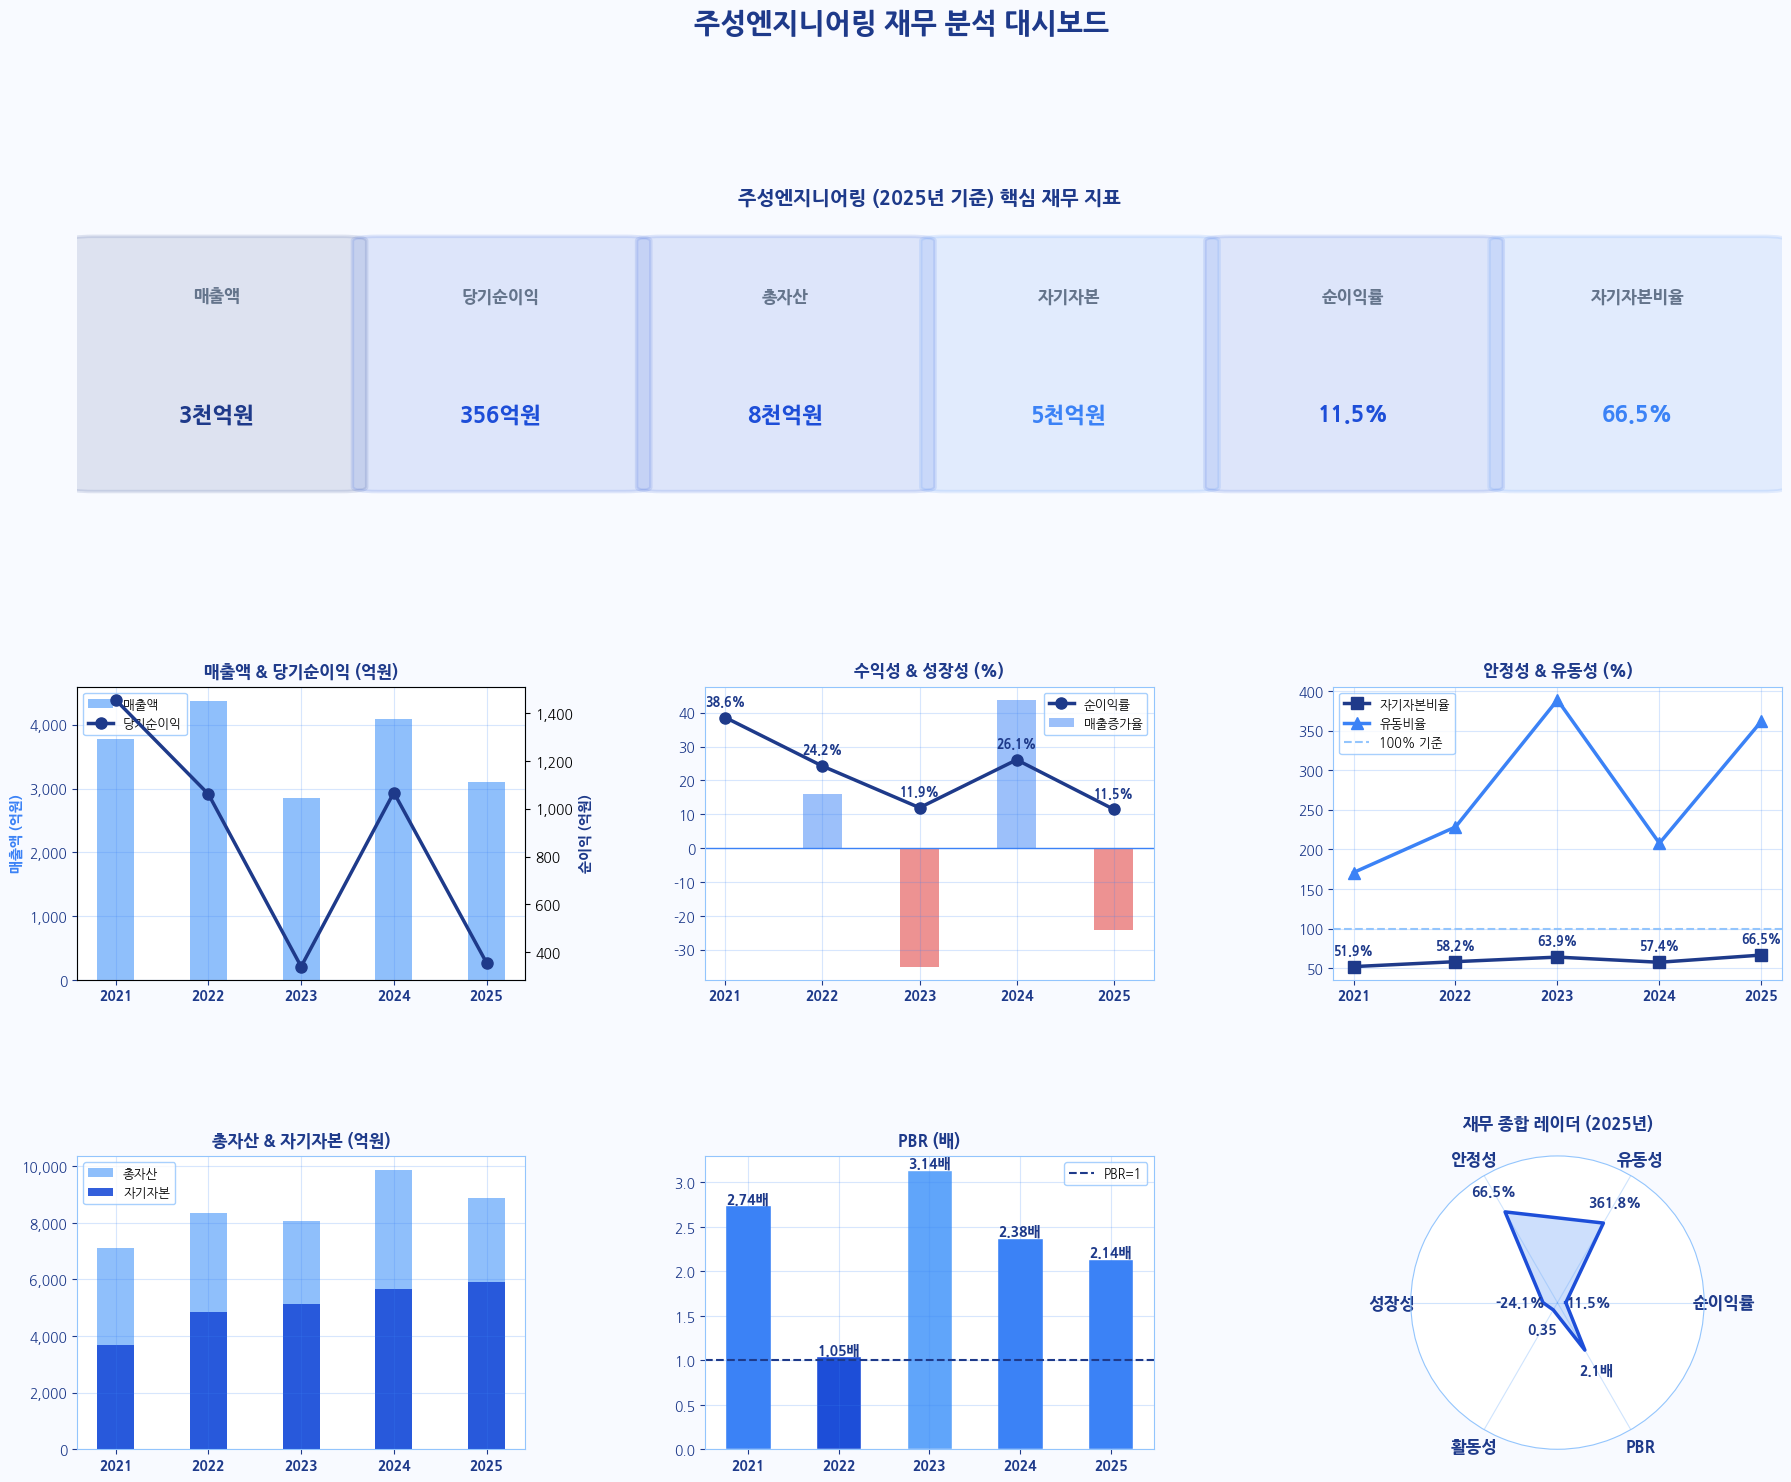

재무 대시보드 완료! (2025년 기준)

[DB 저장 단위 확인]
  revenue      = 3,106  →  3천억원
  total_assets = 8,878  →  8천억원


In [9]:
df_f = pd.read_sql(
    'SELECT * FROM '+FIN_TABLE+' WHERE code='+repr(STOCK_CODE)+' ORDER BY year',
    engine)

if len(df_f) == 0:
    print('재무 데이터 없음 — 섹션 3을 먼저 실행하세요.')
else:
    # ── 재무비율 계산 ──────────────────────────────────────────
    df_f = df_f.copy()
    for col in ['total_assets','current_assets','current_liab','equity',
                'revenue','net_income','adj_price','adj_shares']:
        df_f[col] = pd.to_numeric(df_f[col], errors='coerce')

    df_f['매출액순이익률'] = df_f['net_income']   / df_f['revenue'].replace(0,None) * 100
    df_f['매출액증가율']   = df_f['revenue'].pct_change() * 100
    df_f['유동비율']       = df_f['current_assets'] / df_f['current_liab'].replace(0,None) * 100
    df_f['자기자본비율']   = df_f['equity'] / df_f['total_assets'].replace(0,None) * 100
    df_f['총자산회전율']   = df_f['revenue'] / df_f['total_assets'].replace(0,None)
    # 시총(원) = 수정주가(원) × 수정주식수(주)
    # equity는 DB에 억원 단위로 저장 → × 1e8 해서 원으로 변환
    시총 = df_f['adj_price'] * df_f['adj_shares']          # 원 단위
    df_f['PBR'] = 시총 / (df_f['equity'].replace(0,None) * 1e8)  # 원/원

    latest = df_f.iloc[-1]

    # ── 단위: DB 값이 억원 단위임을 가정 ─────────────────────
    def _fmt(v):
        if v is None or (isinstance(v,float) and np.isnan(v)): return 'N/A'
        v = float(v)
        if   abs(v) >= 10000: return f'{v/10000:.1f}조원'
        elif abs(v) >= 1000:  return f'{int(v/1000):,}천억원'
        else:                 return f'{int(v):,}억원'

    # ── 블루 팔레트 ───────────────────────────────────────────
    BLUE = {
        'b1': '#1E3A8A',   # 진한 네이비
        'b2': '#1D4ED8',   # 진한 파랑
        'b3': '#3B82F6',   # 중간 파랑
        'b4': '#60A5FA',   # 밝은 파랑
        'b5': '#93C5FD',   # 연한 파랑
        'b6': '#DBEAFE',   # 매우 연한 파랑
        'red':  '#DC2626', # 마이너스 강조
        'gray': '#64748B', # 보조 텍스트
    }

    fig = plt.figure(figsize=(22,16), facecolor='#F8FAFF')
    gs  = gridspec.GridSpec(3,3,figure=fig,hspace=0.6,wspace=0.4)
    fig.suptitle(COMPANY_NAME+' 재무 분석 대시보드',
                fontsize=20,fontweight='bold',color=BLUE['b1'],y=1.01)

    # ── 핵심 지표 카드 ────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0,:])
    ax0.set_facecolor('#F8FAFF'); ax0.axis('off')
    ni_v = latest['net_income']
    ni_color = BLUE['b2'] if (pd.notna(ni_v) and float(ni_v)>=0) else BLUE['red']
    cards = [
        ('매출액',       _fmt(latest['revenue']),      BLUE['b1']),
        ('당기순이익',   _fmt(ni_v),                   ni_color),
        ('총자산',       _fmt(latest['total_assets']), BLUE['b2']),
        ('자기자본',     _fmt(latest['equity']),        BLUE['b3']),
        ('순이익률',
         f"{latest['매출액순이익률']:.1f}%" if pd.notna(latest['매출액순이익률']) else 'N/A',
         BLUE['b2'] if (pd.notna(latest['매출액순이익률']) and latest['매출액순이익률']>=0) else BLUE['red']),
        ('자기자본비율',
         f"{latest['자기자본비율']:.1f}%" if pd.notna(latest['자기자본비율']) else 'N/A',
         BLUE['b3']),
    ]
    for i,(label,val,color) in enumerate(cards):
        x = i/6 + 0.01
        rect = mpatches.FancyBboxPatch((x,0.08),0.145,0.84,
            boxstyle='round,pad=0.015',
            facecolor=color, alpha=0.12,
            edgecolor=color, linewidth=2.5,
            transform=ax0.transAxes)
        ax0.add_patch(rect)
        ax0.text(x+0.072,0.73,label,
                ha='center',va='center',fontsize=12,
                color=BLUE['gray'],transform=ax0.transAxes,fontweight='bold')
        ax0.text(x+0.072,0.33,val,
                ha='center',va='center',fontsize=16,
                color=color,transform=ax0.transAxes,fontweight='bold')
    ax0.set_title(f'{COMPANY_NAME} ({latest["year"]}년 기준) 핵심 재무 지표',
                 fontsize=14,fontweight='bold',color=BLUE['b1'],pad=10)

    # ── 공통 스타일 함수 ──────────────────────────────────────
    def style_ax(ax, title):
        ax.set_title(title, fontsize=12, fontweight='bold', color=BLUE['b1'], pad=8)
        ax.tick_params(labelsize=10, colors=BLUE['b1'])
        ax.grid(True, alpha=0.2, color=BLUE['b3'])
        for spine in ax.spines.values():
            spine.set_edgecolor(BLUE['b5'])

    x_pos = range(len(df_f))

    # ── 매출액 & 당기순이익 ───────────────────────────────────
    ax1  = fig.add_subplot(gs[1,0])
    ax1b = ax1.twinx()
    ax1.bar(x_pos, df_f['revenue'], color=BLUE['b4'], alpha=0.7,
           label='매출액', width=0.4)
    ax1b.plot(x_pos, df_f['net_income'], color=BLUE['b1'],
             marker='o', linewidth=2.5, markersize=8, label='당기순이익')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(df_f['year'], fontsize=10, fontweight='bold', color=BLUE['b1'])
    style_ax(ax1,'매출액 & 당기순이익 (억원)')
    ax1.set_ylabel('매출액 (억원)', color=BLUE['b3'], fontsize=10, fontweight='bold')
    ax1b.set_ylabel('순이익 (억원)', color=BLUE['b1'], fontsize=10, fontweight='bold')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    l1,lb1 = ax1.get_legend_handles_labels()
    l2,lb2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lb1+lb2, fontsize=9, loc='upper left',
              facecolor='white', edgecolor=BLUE['b5'])

    # ── 수익성 & 성장성 ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[1,1])
    growth_colors = [BLUE['b3'] if v>=0 else BLUE['red']
                    for v in df_f['매출액증가율'].fillna(0)]
    ax2.bar(x_pos, df_f['매출액증가율'], color=growth_colors,
           alpha=0.5, label='매출증가율', width=0.4)
    ax2.plot(x_pos, df_f['매출액순이익률'], color=BLUE['b1'],
            marker='o', linewidth=2.5, markersize=8, label='순이익률')
    ax2.axhline(0, color=BLUE['b3'], linewidth=1)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(df_f['year'], fontsize=10, fontweight='bold', color=BLUE['b1'])
    style_ax(ax2,'수익성 & 성장성 (%)')
    ax2.legend(fontsize=9, facecolor='white', edgecolor=BLUE['b5'])
    for xi,v in zip(x_pos, df_f['매출액순이익률']):
        if pd.notna(v):
            ax2.annotate(f'{v:.1f}%', (xi,v), xytext=(0,9),
                        textcoords='offset points', ha='center',
                        fontsize=9, fontweight='bold', color=BLUE['b1'])

    # ── 안정성 & 유동성 ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[1,2])
    ax3.plot(x_pos, df_f['자기자본비율'], color=BLUE['b1'],
            marker='s', linewidth=2.5, markersize=8, label='자기자본비율')
    ax3.plot(x_pos, df_f['유동비율'], color=BLUE['b3'],
            marker='^', linewidth=2.5, markersize=8, label='유동비율')
    ax3.axhline(100, color=BLUE['b5'], linestyle='--', linewidth=1.5, label='100% 기준')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(df_f['year'], fontsize=10, fontweight='bold', color=BLUE['b1'])
    style_ax(ax3,'안정성 & 유동성 (%)')
    ax3.legend(fontsize=9, facecolor='white', edgecolor=BLUE['b5'])
    for xi,v in zip(x_pos, df_f['자기자본비율']):
        if pd.notna(v):
            ax3.annotate(f'{v:.1f}%', (xi,v), xytext=(0,9),
                        textcoords='offset points', ha='center',
                        fontsize=9, fontweight='bold', color=BLUE['b1'])

    # ── 총자산 & 자기자본 ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[2,0])
    ax4.bar(x_pos, df_f['total_assets'], color=BLUE['b4'],
           alpha=0.7, label='총자산', width=0.4)
    ax4.bar(x_pos, df_f['equity'], color=BLUE['b2'],
           alpha=0.9, label='자기자본', width=0.4)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(df_f['year'], fontsize=10, fontweight='bold', color=BLUE['b1'])
    style_ax(ax4,'총자산 & 자기자본 (억원)')
    ax4.legend(fontsize=9, facecolor='white', edgecolor=BLUE['b5'])
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:,.0f}'))

    # ── PBR ──────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2,1])
    pbr_colors = [BLUE['b2'] if (v and v<1.5)
                 else BLUE['b3'] if (v and v<3)
                 else BLUE['b4'] for v in df_f['PBR']]
    bars5 = ax5.bar(x_pos, df_f['PBR'], color=pbr_colors, width=0.5, edgecolor='white')
    ax5.axhline(1, color=BLUE['b1'], linestyle='--', linewidth=1.5, label='PBR=1')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(df_f['year'], fontsize=10, fontweight='bold', color=BLUE['b1'])
    style_ax(ax5,'PBR (배)')
    ax5.legend(fontsize=9, facecolor='white', edgecolor=BLUE['b5'])
    for bar,v in zip(bars5, df_f['PBR']):
        if pd.notna(v):
            ax5.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.03,
                    f'{v:.2f}배',
                    ha='center', fontsize=10, fontweight='bold', color=BLUE['b1'])

    # ── 레이더 차트 ───────────────────────────────────────────
    # 명확히 표시 가능한 4개 지표만 사용
    ax6 = fig.add_subplot(gs[2,2], polar=True)
    radar_items = [
        ('순이익률',   '매출액순이익률', '%'),
        ('유동성',     '유동비율',       '%'),
        ('안정성',     '자기자본비율',   '%'),
        ('성장성',     '매출액증가율',   '%'),
        ('활동성',     '총자산회전율',   ''),
        ('PBR',        'PBR',            '배'),
    ]
    r_labels = [it[0] for it in radar_items]
    r_cols   = [it[1] for it in radar_items]
    r_units  = [it[2] for it in radar_items]
    N = len(r_labels)

    # 5년 데이터 기준 0~1 정규화 (음수 포함)
    norms = []
    raw_v = []
    for col in r_cols:
        v     = latest[col] if pd.notna(latest[col]) else 0
        col_v = df_f[col].dropna()
        raw_v.append(v)
        if len(col_v) > 0:
            vmin = col_v.min()
            vmax = col_v.max()
            rng  = vmax - vmin
            norm = (v - vmin)/rng if rng > 0 else 0.5
            norms.append(max(0.08, min(1.0, norm)))
        else:
            norms.append(0.5)

    angles       = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    norms_plot   = norms  + norms[:1]
    angles_plot  = angles + angles[:1]

    ax6.plot(angles_plot, norms_plot,
            color=BLUE['b2'], linewidth=2.5)
    ax6.fill(angles_plot, norms_plot,
            alpha=0.25, color=BLUE['b3'])

    # 꼭짓점에 실제 값 표시
    for angle, norm, v, unit in zip(angles, norms, raw_v, r_units):
        val_str = f'{v:.1f}{unit}' if unit else f'{v:.2f}'
        ax6.text(angle, min(norm+0.22, 1.35), val_str,
                ha='center', va='center',
                fontsize=10, fontweight='bold', color=BLUE['b1'])

    ax6.set_xticks(angles)
    ax6.set_xticklabels(r_labels, fontsize=12, fontweight='bold', color=BLUE['b1'])
    ax6.set_ylim(0, 1.4)
    ax6.set_yticks([])
    ax6.set_title('재무 종합 레이더 ('+str(latest['year'])+'년)',
                 fontsize=12, fontweight='bold', color=BLUE['b1'], pad=20)
    ax6.spines['polar'].set_color(BLUE['b5'])
    ax6.grid(True, alpha=0.3, color=BLUE['b4'])

    plt.savefig('company_financial_dashboard.png', dpi=130,
               bbox_inches='tight', facecolor='#F8FAFF')
    plt.show()
    print('재무 대시보드 완료! ('+str(latest['year'])+'년 기준)')
    print()
    print('[DB 저장 단위 확인]')
    print(f'  revenue      = {latest["revenue"]:,}  →  {_fmt(latest["revenue"])}')
    print(f'  total_assets = {latest["total_assets"]:,}  →  {_fmt(latest["total_assets"])}')
